<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

# 感情分析の説明

- 感情分析とは、文章に含まれる**肯定的・否定的な感情や評価を自動的に判定するテキスト分析手法**である。

- 例えば、次のような文章を分析することができる。
  - 商品レビュー
  - 店舗の口コミ
  - SNSへの投稿
  - アンケートの自由記述

- 感情分析を行うことで、文章を書いた人が**どのような印象や評価を持っているか**を分析できる。

- 今回は、カフェの口コミデータに対して、**学習済みの自然言語処理モデル**を用いて感情分析を行う。

- 各口コミの文章をモデルに入力し、主に次のような感情に分類する。
  - **Positive**：肯定的な内容
  - **Negative**：否定的な内容

- 感情分析の結果について、次の内容を確認する。
  - Positive、Negativeと判定された**口コミの件数**
  - Positive、Negativeの**割合**
  - **星評価（1～5）と感情分析結果の関係**

- これにより、**数値として与えられた星評価と、口コミ文章から読み取れる感情との関係**を分析する。


----

# データの読み込み

**プロンプトの例**<br>
「データフォルダの中のテキストフォルダに入っている架空カフェ店口コミデータ.xlsxというExcelファイルを読み込んで、表示してください。」

# 感情分析の実行

**プロンプトの例**<br>
「読み込んだ各口コミに対して感情分析を行い、ポジティブな内容かネガティブな内容かを判定して、結果を表示してください。感情分析には機械学習モデルを使用してください。」

# 感情分析結果の解析

**プロンプトの例**<br>
「感情分析の結果から、ポジティブな口コミとネガティブな口コミの割合の集計結果とグラフを作成してください。」<br>「星評価別にポジティブな口コミとネガティブな口コミの集計結果とグラフを作成してください。」

----
----
----
----
----
----
----
----
----
----

# プログラム例

## データの読み込み

In [19]:
import pandas as pd

# Excelファイルを読み込み
file_path = '../データ/テキスト/架空カフェ店口コミデータ.xlsx'

try:
    df = pd.read_excel(file_path)
    print("Excelファイルを読み込みました。\n")
    print(f"データ形状：{df.shape}")
    print(f"\nカラム：{list(df.columns)}\n")
    display(df)
except FileNotFoundError:
    print(f"ファイルが見つかりません：{file_path}")
except Exception as e:
    print(f"エラーが発生しました：{e}")

Excelファイルを読み込みました。

データ形状：(100, 3)

カラム：['ID', '評価(1-5)', '口コミ']



,ID,評価(1-5),口コミ
0,1,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。良い時間を過ごせました。
1,2,2,混雑していて席がなかなか空きませんでした。あまりおすすめできません。
2,3,1,混雑していて席がなかなか空きませんでした。次は別のお店を利用するかもしれません。
3,4,4,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。
4,5,5,アクセスが良く、また来たいと思えるカフェでした。良い時間を過ごせました。
...,...,...,...
95,96,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。友人にもおすすめしたいです。
96,97,4,静かで作業にも集中できる良い環境でした。友人にもおすすめしたいです。
97,98,5,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。
98,99,5,静かで作業にも集中できる良い環境でした。友人にもおすすめしたいです。


## 感情分析の実行

In [20]:
!pip install -q transformers

from transformers import pipeline
import torch

# GPUが利用可能ならGPUを使用
device = 0 if torch.cuda.is_available() else -1

# 感情分析モデルを読み込む
sentiment_analyzer = pipeline(
    "text-classification",
    model="tabularisai/multilingual-sentiment-analysis",
    device=device
)

print("感情分析モデルを読み込みました。")

# 口コミ列をリストに変換
reviews = df["口コミ"].fillna("").astype(str).tolist()

# すべての口コミを感情分析
results = sentiment_analyzer(
    reviews,
    truncation=True,
    batch_size=32
)

# 結果をDataFrameに追加
df["感情"] = [result["label"] for result in results]
df["感情スコア"] = [result["score"] for result in results]

display(df)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3625.09it/s]


感情分析モデルを読み込みました。


,ID,評価(1-5),口コミ,感情,感情スコア
0,1,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。良い時間を過ごせました。,Positive,0.854083
1,2,2,混雑していて席がなかなか空きませんでした。あまりおすすめできません。,Negative,0.582174
2,3,1,混雑していて席がなかなか空きませんでした。次は別のお店を利用するかもしれません。,Negative,0.630029
3,4,4,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。,Positive,0.906317
4,5,5,アクセスが良く、また来たいと思えるカフェでした。良い時間を過ごせました。,Positive,0.906057
...,...,...,...,...,...
95,96,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。友人にもおすすめしたいです。,Positive,0.847671
96,97,4,静かで作業にも集中できる良い環境でした。友人にもおすすめしたいです。,Positive,0.872125
97,98,5,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。,Positive,0.906317
98,99,5,静かで作業にも集中できる良い環境でした。友人にもおすすめしたいです。,Positive,0.872125


## 感情分析結果の解析

### Positive / Negative の件数と割合

,件数,割合(%)
感情,,
Positive,70,70.0
Negative,25,25.0
Neutral,4,4.0
Very Negative,1,1.0


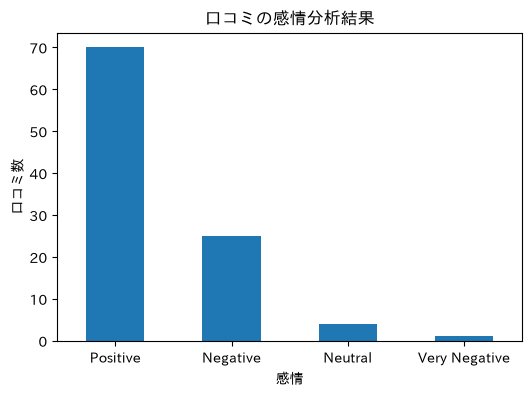

In [21]:
# 感情ごとの件数
sentiment_count = df["感情"].value_counts()

# 感情ごとの割合
sentiment_ratio = df["感情"].value_counts(normalize=True) * 100

# 表にまとめる
sentiment_summary = pd.DataFrame({
    "件数": sentiment_count,
    "割合(%)": sentiment_ratio.round(1)
})

display(sentiment_summary)


# 棒グラフ作成
import matplotlib.pyplot as plt
import matplotlib_fontja

sentiment_count.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("口コミの感情分析結果")
plt.xlabel("感情")
plt.ylabel("口コミ数")
plt.xticks(rotation=0)
plt.show()

### 星評価と感情分析結果を比較

感情,Negative,Neutral,Positive,Very Negative
評価(1-5),,,,
1,75.0,18.8,0.0,6.2
2,92.9,7.1,0.0,0.0
4,0.0,0.0,100.0,0.0
5,0.0,0.0,100.0,0.0


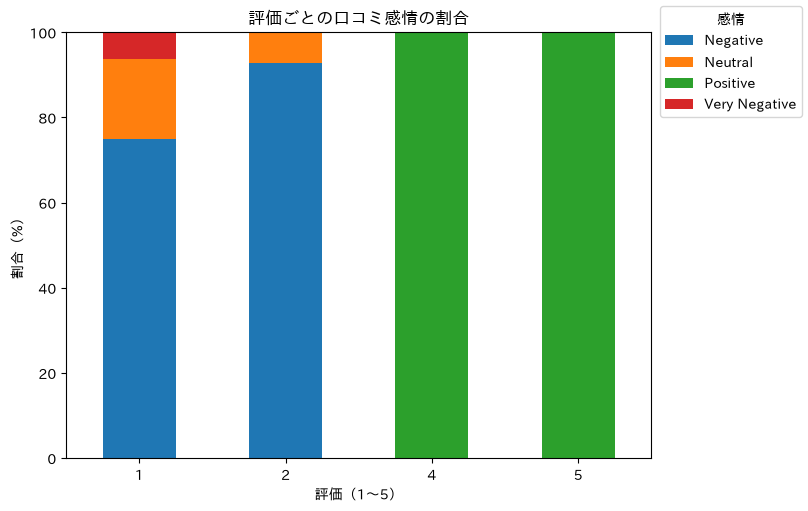

In [22]:
# 評価（1～5）ごとに、各感情が占める割合を計算
cross_ratio = pd.crosstab(
    df["評価(1-5)"],
    df["感情"],
    normalize="index"
) * 100

# 集計結果を小数第1位まで表示
display(cross_ratio.round(1))

# グラフを作成
fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

# 評価ごとの感情割合を積み上げ棒グラフで表示
cross_ratio.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    legend=False
)

# グラフのタイトルと軸ラベルを設定
ax.set_title("評価ごとの口コミ感情の割合")
ax.set_xlabel("評価（1～5）")
ax.set_ylabel("割合（%）")

# 横軸のラベルを横向きに表示
ax.tick_params(
    axis="x",
    rotation=0
)

# レジェンドをグラフの右外側に表示
fig.legend(
    title="感情",
    loc="outside right upper"
)

# グラフを表示
plt.show()